# Top Results Visualization

Visualizing top performing results from fully optimized GA run:
`results/fully_optimized_ga_large_progressive_opt4_20250810_220234/aggregated_results.pkl`

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from src.neuron import *
from src.utils import *
from src.constants import * 
from src.network import *
from src.validation import *
from src.genetic_algorithm import *
from copy import copy
from datetime import datetime
from IPython.display import display, HTML
import networkx as nx
from ipywidgets import interact, IntSlider
from scipy.optimize import curve_fit

In [2]:
# Load aggregated results
file_path = 'results/fully_optimized_ga_large_progressive_opt4_20250810_220234/aggregated_results.pkl'

with open(file_path, 'rb') as f:
    data = pickle.load(f)

print('Data keys:', list(data.keys()))
print('Summary:', data['summary'])
print(f"Total individuals tested: {len(data['all_dna_tested'])}")
print(f"Best overall score: {data['summary']['best_overall_score']}")

Data keys: ['summary', 'all_dna_tested', 'generation_stats', 'process_results', 'config_used']
Summary: {'config_name': 'large', 'num_processes': 10, 'successful_processes': 10, 'num_generations': 100, 'tmax_strategy': 'progressive', 'optimization_level': 4, 'total_runtime': 298.4944679737091, 'total_individuals_tested': 500000, 'best_overall_score': 980, 'individuals_per_second': 1675.0729197568887, 'time_speedup': 1.6666666666666667, 'results_directory': 'results/fully_optimized_ga_large_progressive_opt4_20250810_220234', 'start_time': 1754877754.983043, 'end_time': 1754878053.477511}
Total individuals tested: 500000
Best overall score: 980


In [3]:
# Convert to DataFrame for easier analysis
all_results = pd.DataFrame(data['all_dna_tested'])
print(f"DataFrame shape: {all_results.shape}")
print("Columns:", all_results.columns.tolist())
display(all_results.head())

DataFrame shape: (500000, 13)
Columns: ['process_id', 'generation', 'individual_id', 'dna', 'exp_score', 'cont_score', 'total_score', 'timestamp', 'tmax_used', 'tmax_strategy', 'optimization_level', 'early_termination_used', 'reduced_precision_used']


,process_id,generation,individual_id,dna,exp_score,cont_score,total_score,timestamp,tmax_used,tmax_strategy,optimization_level,early_termination_used,reduced_precision_used
0,0,0,0,"[290, 176, 366, 276, -177, -54, -229, -393, -2...",77,67,144,1.754878e+09,2000,progressive,4,True,True
1,0,0,1,"[206, 9, 159, 293, -37, -269, -402, -45, -313,...",106,66,172,1.754878e+09,2000,progressive,4,True,True
2,0,0,2,"[224, 68, 64, 403, -136, -39, -417, -437, -373...",140,180,320,1.754878e+09,2000,progressive,4,True,True
3,0,0,3,"[468, 477, 206, 194, -329, -188, -46, -26, -43...",149,179,328,1.754878e+09,2000,progressive,4,True,True
4,0,0,4,"[374, 109, 231, 316, -220, -119, -403, -99, -4...",102,102,204,1.754878e+09,2000,progressive,4,True,True


In [4]:
# Get top performing results
top_results = all_results.nlargest(100, 'total_score')
print(f"Top 100 score range: {top_results['total_score'].min()} to {top_results['total_score'].max()}")
display(top_results[['process_id', 'generation', 'total_score', 'exp_score', 'cont_score']].head(10))

Top 100 score range: 978 to 980


,process_id,generation,total_score,exp_score,cont_score
49739,0,99,980,480,500
49933,0,99,980,480,500
49116,0,98,979,479,500
49500,0,99,979,479,500
49613,0,99,979,479,500
49733,0,99,979,479,500
49862,0,99,979,479,500
49868,0,99,979,479,500
47547,0,95,978,478,500
47830,0,95,978,478,500


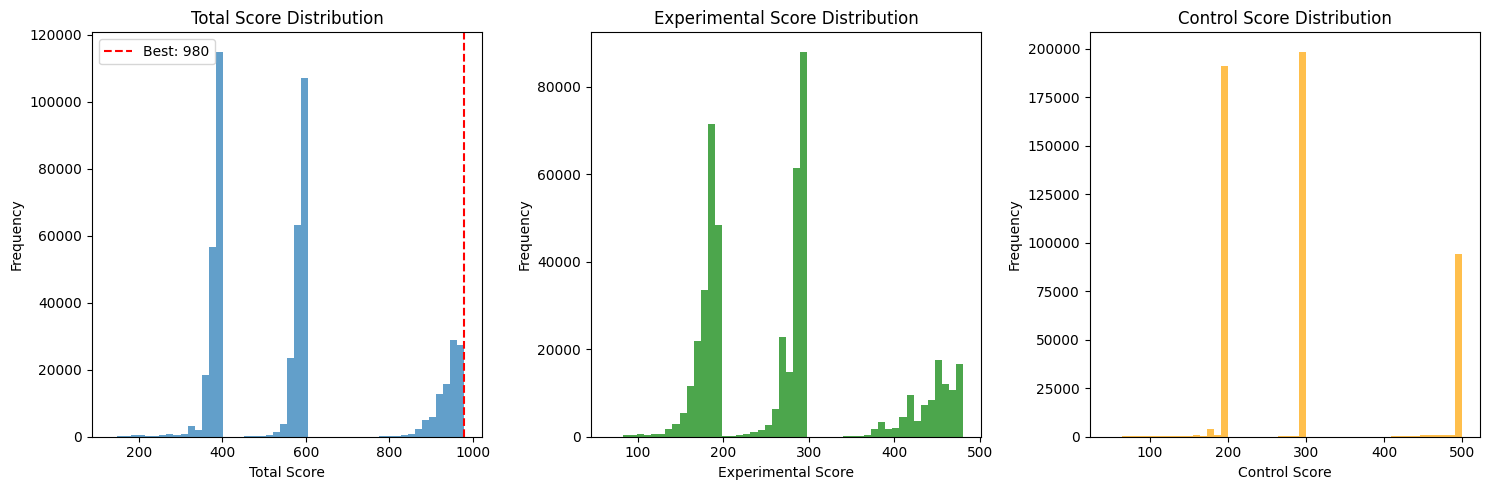

In [5]:
# Score distribution analysis
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(all_results['total_score'], bins=50, alpha=0.7)
plt.axvline(top_results['total_score'].iloc[0], color='red', linestyle='--', label=f'Best: {top_results["total_score"].iloc[0]}')
plt.xlabel('Total Score')
plt.ylabel('Frequency')
plt.title('Total Score Distribution')
plt.legend()

plt.subplot(1, 3, 2)
plt.hist(all_results['exp_score'], bins=50, alpha=0.7, color='green')
plt.xlabel('Experimental Score')
plt.ylabel('Frequency')
plt.title('Experimental Score Distribution')

plt.subplot(1, 3, 3)
plt.hist(all_results['cont_score'], bins=50, alpha=0.7, color='orange')
plt.xlabel('Control Score')
plt.ylabel('Frequency')
plt.title('Control Score Distribution')

plt.tight_layout()
plt.show()

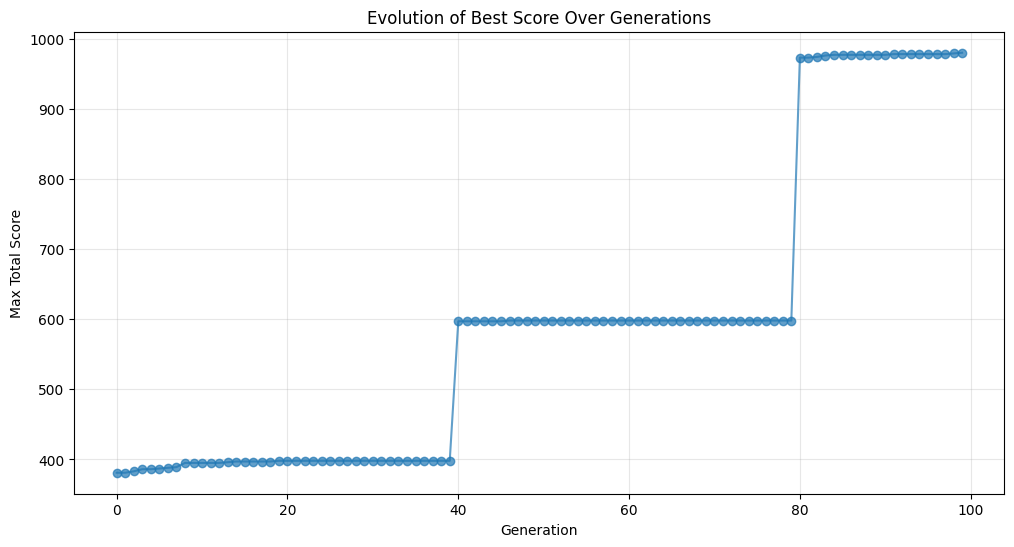

Final generation: 99
Best score achieved: 980


In [6]:
# Evolution over generations - max score per generation
max_scores_per_gen = all_results.groupby('generation')['total_score'].max().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(max_scores_per_gen['generation'], max_scores_per_gen['total_score'], 'o-', alpha=0.7)
plt.xlabel('Generation')
plt.ylabel('Max Total Score')
plt.title('Evolution of Best Score Over Generations')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Final generation: {max_scores_per_gen['generation'].max()}")
print(f"Best score achieved: {max_scores_per_gen['total_score'].max()}")

In [7]:
# Average synapse weights for top performers
top_100 = all_results.nlargest(100, 'total_score')

# Calculate synapse usage frequency and average weights
synapse_stats = []
for i in range(len(ACTIVE_SYNAPSES)):
    weights = [dna[i] for dna in top_100['dna']]
    non_zero_count = sum(1 for w in weights if w != 0)
    usage_frequency = non_zero_count / len(top_100)
    avg_weight = sum(w for w in weights if w != 0) / max(non_zero_count, 1)
    
    synapse_stats.append({
        'synapse': f"{ACTIVE_SYNAPSES[i][0]} -> {ACTIVE_SYNAPSES[i][1]}",
        'usage_frequency': usage_frequency,
        'avg_weight': avg_weight,
        'non_zero_count': non_zero_count
    })

synapse_df = pd.DataFrame(synapse_stats)
synapse_df = synapse_df.sort_values('usage_frequency', ascending=False)

print("Top synapses by usage frequency in top 100 performers:")
display(synapse_df.head(20))

Top synapses by usage frequency in top 100 performers:


,synapse,usage_frequency,avg_weight,non_zero_count
0,Somat -> ALMprep,1.0,480.06,100
15,SNR2 -> VMprep,1.0,-52.97,100
31,ALMresp -> MSN1,1.0,79.23,100
28,ALMinter -> MSN1,1.0,-83.49,100
27,ALMprep -> MSN3,1.0,262.22,100
36,ALMresp -> VMprep,1.0,127.57,100
23,VMresp -> ALMinter,1.0,222.24,100
22,VMresp -> ALMprep,1.0,30.57,100
39,MSN1 -> MSN3,1.0,-46.49,100
40,MSN2 -> MSN1,1.0,-171.23,100


In [8]:
# Critical synapses (used in 90%+ of top performers)
critical_synapses = synapse_df[synapse_df['usage_frequency'] >= 0.9]
print(f"Critical synapses (90%+ usage in top 100): {len(critical_synapses)}")
display(critical_synapses)

Critical synapses (90%+ usage in top 100): 33


,synapse,usage_frequency,avg_weight,non_zero_count
0,Somat -> ALMprep,1.00,480.060000,100
15,SNR2 -> VMprep,1.00,-52.970000,100
31,ALMresp -> MSN1,1.00,79.230000,100
28,ALMinter -> MSN1,1.00,-83.490000,100
27,ALMprep -> MSN3,1.00,262.220000,100
36,ALMresp -> VMprep,1.00,127.570000,100
23,VMresp -> ALMinter,1.00,222.240000,100
22,VMresp -> ALMprep,1.00,30.570000,100
39,MSN1 -> MSN3,1.00,-46.490000,100
40,MSN2 -> MSN1,1.00,-171.230000,100


In [9]:
# Best individual analysis
best_individual = top_results.iloc[0]
best_dna = best_individual['dna']

print(f"Best individual score: {best_individual['total_score']} (exp: {best_individual['exp_score']}, cont: {best_individual['cont_score']})")
print(f"Generation: {best_individual['generation']}, Process: {best_individual['process_id']}")
print(f"TMAX used: {best_individual['tmax_used']}, Strategy: {best_individual['tmax_strategy']}")
print(f"Optimization level: {best_individual['optimization_level']}")

# Create labeled series for best DNA
best_dna_labeled = pd.Series(best_dna, index=[f"{pair[0]} -> {pair[1]}" for pair in ACTIVE_SYNAPSES])
non_zero_synapses = best_dna_labeled[best_dna_labeled != 0]

print(f"\nNumber of active synapses: {len(non_zero_synapses)}")
print("\nActive synapses in best individual:")
display(non_zero_synapses.sort_values(key=abs, ascending=False))

Best individual score: 980 (exp: 480, cont: 500)
Generation: 99, Process: 0
TMAX used: 5000, Strategy: progressive
Optimization level: 4

Number of active synapses: 43

Active synapses in best individual:


Somat -> ALMprep       500
ALMprep -> MSN2        500
Somat -> MSN3          500
ALMresp -> MSN2        500
MSN2 -> SNR3          -500
ALMinter -> ALMresp   -485
ALMprep -> MSN3        478
MSN1 -> SNR3          -469
MSN3 -> SNR3          -391
THALgo -> ALMinter     349
ALMprep -> VMprep      284
MSN3 -> MSN1          -284
ALMinter -> MSN1      -276
VMresp -> ALMinter     228
MSN3 -> SNR1          -199
MSN1 -> MSN3           -86
Somat -> MSN2           84
ALMresp -> VMresp       79
ALMinter -> MSN2       -68
ALMresp -> ALMinter     64
SNR3 -> VMresp         -61
SNR1 -> VMprep         -60
ALMresp -> MSN1         57
ALMinter -> ALMprep    -57
VMresp -> ALMresp       54
MSN2 -> MSN1           -52
SNR2 -> VMprep         -47
ALMresp -> VMprep       46
ALMresp -> MSN3         43
VMresp -> ALMprep       40
MSN2 -> MSN3           -39
VMprep -> ALMprep       33
THALgo -> ALMresp       32
PPN -> THALgo           27
ALMresp -> ALMprep      25
ALMinter -> MSN3       -24
MSN3 -> SNR2           -24
M

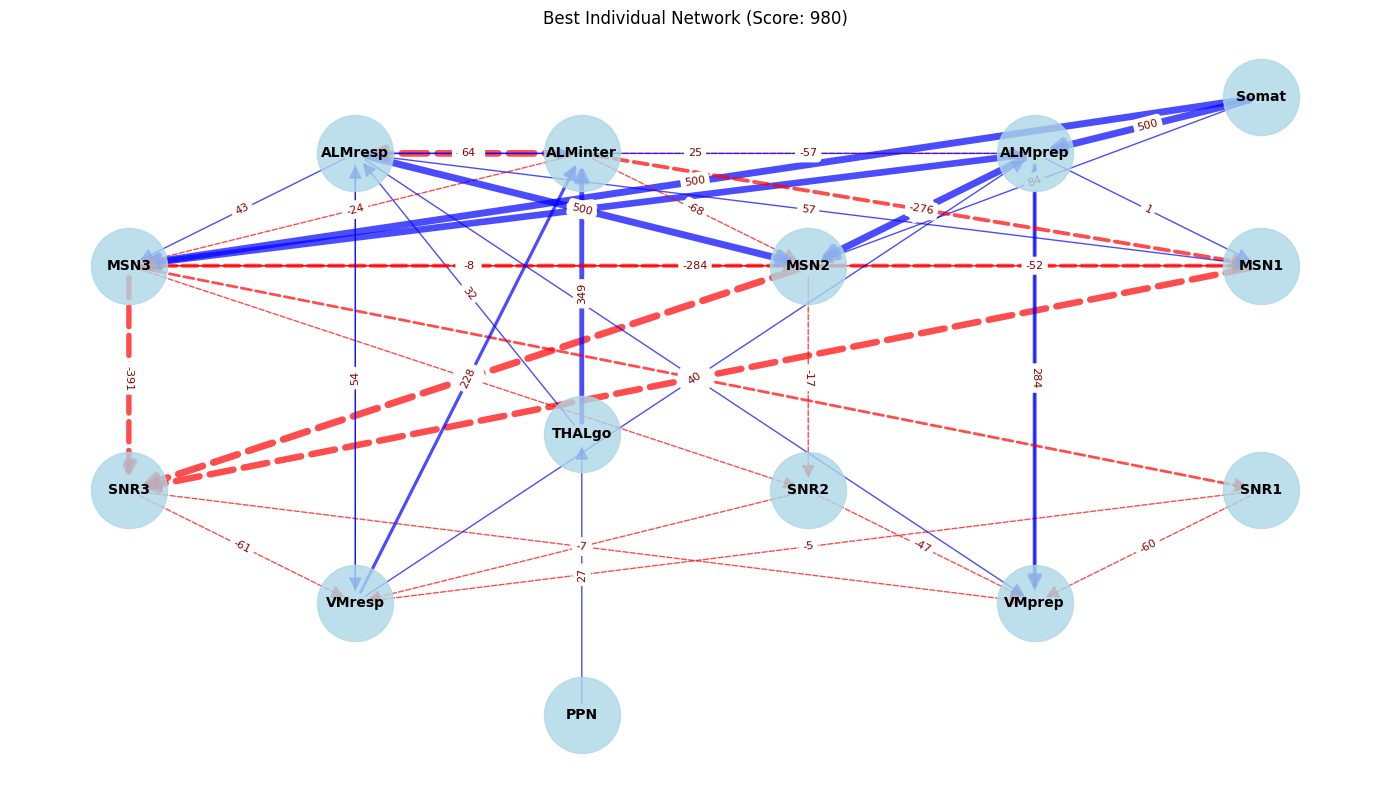

In [10]:
# Network visualization of best individual
def plot_network(dna, title="Network Diagram"):
    G = nx.DiGraph()
    G.add_nodes_from(NEURON_NAMES)
    
    # Add edges for non-zero connections
    for i, weight in enumerate(dna):
        if weight != 0:
            source, target = ACTIVE_SYNAPSES[i]
            G.add_edge(source, target, weight=weight)
    
    # Custom positions (from original notebook)
    custom_pos = {
        'Somat': (5, 5.5),
        'MSN1': (5, 4),
        'MSN2': (3, 4),
        'MSN3': (0, 4),
        'SNR1': (5, 2),
        'SNR2': (3, 2),
        'SNR3': (0, 2),
        'ALMinter': (2, 5),
        'PPN': (2, 0),
        'THALgo': (2, 2.5),
        'VMprep': (4, 1),
        'ALMprep': (4, 5),
        'ALMresp': (1, 5),
        'VMresp': (1, 1)
    }
    
    plt.figure(figsize=(14, 8))
    
    # Draw nodes
    nx.draw_networkx_nodes(G, pos=custom_pos, node_size=3000, node_color='lightblue', alpha=0.8)
    nx.draw_networkx_labels(G, pos=custom_pos, font_size=10, font_weight='bold')
    
    # Draw edges with width proportional to weight magnitude
    edges = G.edges(data=True)
    edge_weights = [abs(data['weight']) for _, _, data in edges]
    edge_widths = [max(1, w/100) for w in edge_weights]  # Scale width
    edge_colors = ['red' if data['weight'] < 0 else 'blue' for _, _, data in edges]
    edge_styles = ['dashed' if data['weight'] < 0 else 'solid' for _, _, data in edges]
    
    nx.draw_networkx_edges(G, pos=custom_pos, width=edge_widths, edge_color=edge_colors, 
                          style=edge_styles, arrows=True, arrowsize=20, alpha=0.7)
    
    # Add edge labels
    edge_labels = {(u, v): str(d['weight']) for u, v, d in edges}
    nx.draw_networkx_edge_labels(G, pos=custom_pos, edge_labels=edge_labels, 
                                font_size=8, font_color='darkred')
    
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_network(best_dna, f"Best Individual Network (Score: {best_individual['total_score']})")

In [11]:
# Run experiment on best individual
print("Running experiment on best individual...")
try:
    result = run_experiment(best_dna, [1,1,0,1])
    print(f"Experiment result: {result}")
except Exception as e:
    print(f"Error running experiment: {e}")

Running experiment on best individual...
Error running experiment: name 'run_experiment' is not defined


In [ ]:
# Compare top 10 individuals
top_10 = top_results.head(10)

def plot_top_networks(n=5):
    fig, axes = plt.subplots(1, n, figsize=(20, 4))
    if n == 1:
        axes = [axes]
    
    for i in range(n):
        individual = top_10.iloc[i]
        dna = individual['dna']
        
        G = nx.DiGraph()
        G.add_nodes_from(NEURON_NAMES)
        
        for j, weight in enumerate(dna):
            if weight != 0:
                source, target = ACTIVE_SYNAPSES[j]
                G.add_edge(source, target, weight=weight)
        
        custom_pos = {
            'Somat': (5, 5.5), 'MSN1': (5, 4), 'MSN2': (3, 4), 'MSN3': (0, 4),
            'SNR1': (5, 2), 'SNR2': (3, 2), 'SNR3': (0, 2), 'ALMinter': (2, 5),
            'PPN': (2, 0), 'THALgo': (2, 2.5), 'VMprep': (4, 1), 'ALMprep': (4, 5),
            'ALMresp': (1, 5), 'VMresp': (1, 1)
        }
        
        axes[i].set_title(f"Rank {i+1}: Score {individual['total_score']}\nGen {individual['generation']}")
        
        nx.draw(G, pos=custom_pos, ax=axes[i], with_labels=True, node_size=500, 
               node_color='lightblue', font_size=6, arrows=True, arrowsize=10)
        
        axes[i].set_aspect('equal')
    
    plt.tight_layout()
    plt.show()

plot_top_networks(5)

print("\nTop 10 individuals summary:")
display(top_10[['generation', 'total_score', 'exp_score', 'cont_score', 'tmax_used', 'optimization_level']])